In [1]:
import numpy as np
import xarray as xr
import toml
import munch
from tqdm import tqdm
import torch
import datetime
import zarr

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display, clear_output
import ipywidgets as widgets
import os

os.environ['RUCIO_CONFIG'] = '/ceph/hpc/home/ciangottinid/ML4Fires/rucio.cfg'

config = munch.munchify(toml.load("/ceph/hpc/home/ciangottinid/ML4Fires/config/configuration.toml"))
server_config_path = config.paths.server_config
local_config_path = config.paths.local_config

from typing import Any
from rucio.client.client import Client
from types import SimpleNamespace
#from rucio.client.uploadclient import UploadClient
rucio = Client()
from Fires._utilities.utils_inference import get_cmip6_inference

from Fires._utilities.utils_mlflow import load_model_from_mlflow
from Fires._utilities.utils_inference import get_cmip6_inference,load_cmip6_files_from_config, get_cmip6_files_rucio,_get_file_list

#### these two cells for Rucio

In [2]:
variable = "*"
frequency = "*"
model = "CMCC-ESM2"
scenario = "*"
filters = variable + "_*_" + model + "_" + scenario + "_*.nc"
listing = rucio.list_dids(scope="abennasser", filters={"name": filters}, did_type="file")




Please use your internet browser, go to:

    https://rucio-intertwin-testbed-auth.desy.de/auth/oidc_redirect?GzDibr6eU8FEEUUQkdMJDhz    

and authenticate with your Identity Provider.
Copy paste the code from the browser to the terminal and press enter:


 SRj38yxGi3vrmtL6jodBIJJfVtHxJwNFjEN9rDEhYbgxPI1bfE


In [3]:
from IPython.display import display, clear_output
import ipywidgets as widgets

# -----------------------------
# UI widgets
# -----------------------------
scenario = widgets.Dropdown(
    options=[
        ('SSP126', 'ssp126'),
        ('SSP245', 'ssp245'),
        ('SSP370', 'ssp370'),
        ('SSP585', 'ssp585')
    ],
    value='ssp126',
    description='CMIP6 Scenario:',
    style={'description_width': '150px'}
)

year_range = widgets.IntRangeSlider(
    value=[2030, 2035],
    min=2015,
    max=2100,
    step=1,
    description='Year Range:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='400px')
)

run_button = widgets.Button(
    description='Load CMIP6 Data',
    button_style='success',
    icon='cloud-download'
)

output = widgets.Output()

# -----------------------------
# Callback for file loading
# -----------------------------
def on_run_button_clicked(b):
    with output:
        clear_output()
        selected_scenario = scenario.value
        selected_years = tuple(year_range.value)

        print(f"📌 Scenario selected: {selected_scenario}")
        print(f"📆 Year range selected: {selected_years}")

        try:
            files_dict, date_windows = load_cmip6_files_from_config(
                scenario=selected_scenario,
                year_range=selected_years,
                server_config_path=server_config_path,
                local_config_path=local_config_path
            )
            print("✅ Files loaded successfully.\n")
            for var, files in files_dict.items():
                print(f"🔹 {var}: {len(files)} file(s)")
        except Exception as e:
            print(f"❌ Error loading files:\n{e}")

# Hook up button
run_button.on_click(on_run_button_clicked)

# -----------------------------
# Display the full UI
# -----------------------------
display(widgets.VBox([ 
    widgets.HBox([scenario, year_range]),
    run_button,
    output
]))


### this one for the local 

In [2]:
import ipywidgets as widgets

scenario = widgets.Dropdown(
    options=[('SSP126', 'ssp126'),
             ('SSP245', 'ssp245'),
             ('SSP370', 'ssp370'),
             ('SSP585', 'ssp585')],
    value = 'ssp126',
    style={'description_width': '150px'}, 
    description='CMIP6 Scenario', disabled=False,)

year_range = widgets.IntRangeSlider(
    value=[2030, 2035],        # initial range
    min=2015,                 # min value
    max=2100,               # max value
    step=1,                # step size
    description='Year range:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px')
)

display(widgets.HBox([scenario, year_range]))

In [4]:
searfire_ds_path = "/ceph/hpc/home/ciangottinid/ML4Fires/data/ML4Fires_copy/data_100km.zarr"
seafire_ds = xr.open_zarr(searfire_ds_path)

In [5]:
# run_name=input()
run_name="last"
registered_model = load_model_from_mlflow(run_name, provenance=True)
# registered_model

Data from MLFlow downloaded in: /jupyter-workspace/persistent-storage/ML4Fires/MLFLOW/last


2025/06/25 13:14:09 WARNING mlflow.pytorch: Stored model version '2.4.1+cu121' does not match installed PyTorch version '2.4.1+cu124'


In [6]:

predictions = get_cmip6_inference(
    seafire_ds=seafire_ds,
    run_name=run_name,
    scenario=scenario.value,
    year_range=tuple(year_range.value),
    model=registered_model,
    server_config_path=server_config_path,
    local_config_path=local_config_path
)

📘 Running inference for scenario: ssp126, years: 2030–2035
Loading the following CMIP6 data files from RUCIO:
  lai: ['/dcache/sling.si/projects/intertwin/abennasser/lai_Eday_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20641231.nc']
  tasmax: ['/dcache/sling.si/projects/intertwin/abennasser/tasmax_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc']
  hur: ['/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20290101-20301231.nc', '/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20310101-20321231.nc', '/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20330101-20341231.nc', '/dcache/sling.si/projects/intertwin/abennasser/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20350101-20361231.nc']
  tasmin: ['/dcache/sling.si/projects/intertwin/abennasser/tasmin_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc']
  pr: ['/dcache/sling.si/projects/intertwin/abennasser/pr_day_CMCC-ESM2_ssp126_r1i1p1f1_g

In [7]:
monthly_agg = widgets.Dropdown(
    options=[('Mean', 'mean'), ('Sum', 'sum'), ('Median', 'median'),
             ('Mode', 'mode')],
    value = 'sum',
    style={'description_width': '150px'}, 
    description='Monthly aggregate', disabled=False,)

monthly_add_period = widgets.Dropdown(
    options=[('1 Month', '1M'), ('2 Months', '2M'), ('4 Months', '4M'),
             ('6 Month', '6M')],
    value = '1M',
    style={'description_width': '150px'}, 
    description='Monthly aggregate period', disabled=False,)

yearly_agg = widgets.Dropdown(
    options=[('Mean', 'mean'), ('Sum', 'sum'), ('Median', 'median'),
             ('Mode', 'mode')],
    value = 'mean',
    style={'description_width': '150px'}, 
    description='Yearly aggregate', disabled=False,)

decadal_agg = widgets.Dropdown(
    options=[('Mean', 'mean'), ('Sum', 'sum'), ('Median', 'median'),
             ('Mode', 'mode')],
    value = 'mean',
    style={'description_width': '150px'}, 
    description='Decadal aggregate', disabled=False,)

display(widgets.HBox([monthly_agg,
                      monthly_add_period]))
        
display(widgets.VBox([yearly_agg,
                      decadal_agg]))


['lai', 'lst_day', 'rel_hum', 'sst', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)
 Mean of data: (180, 360)
 Max: 6467.43017578125 	 Min: 0.009999999776482582
 Lats Max: 635.3800048828125 	 Lons Max: 341.7200012207031
 Mean of data: (180, 360)
 Max: 5846.580078125 	 Min: 0.0
 Lats Max: 634.3200073242188 	 Lons Max: 357.1700134277344


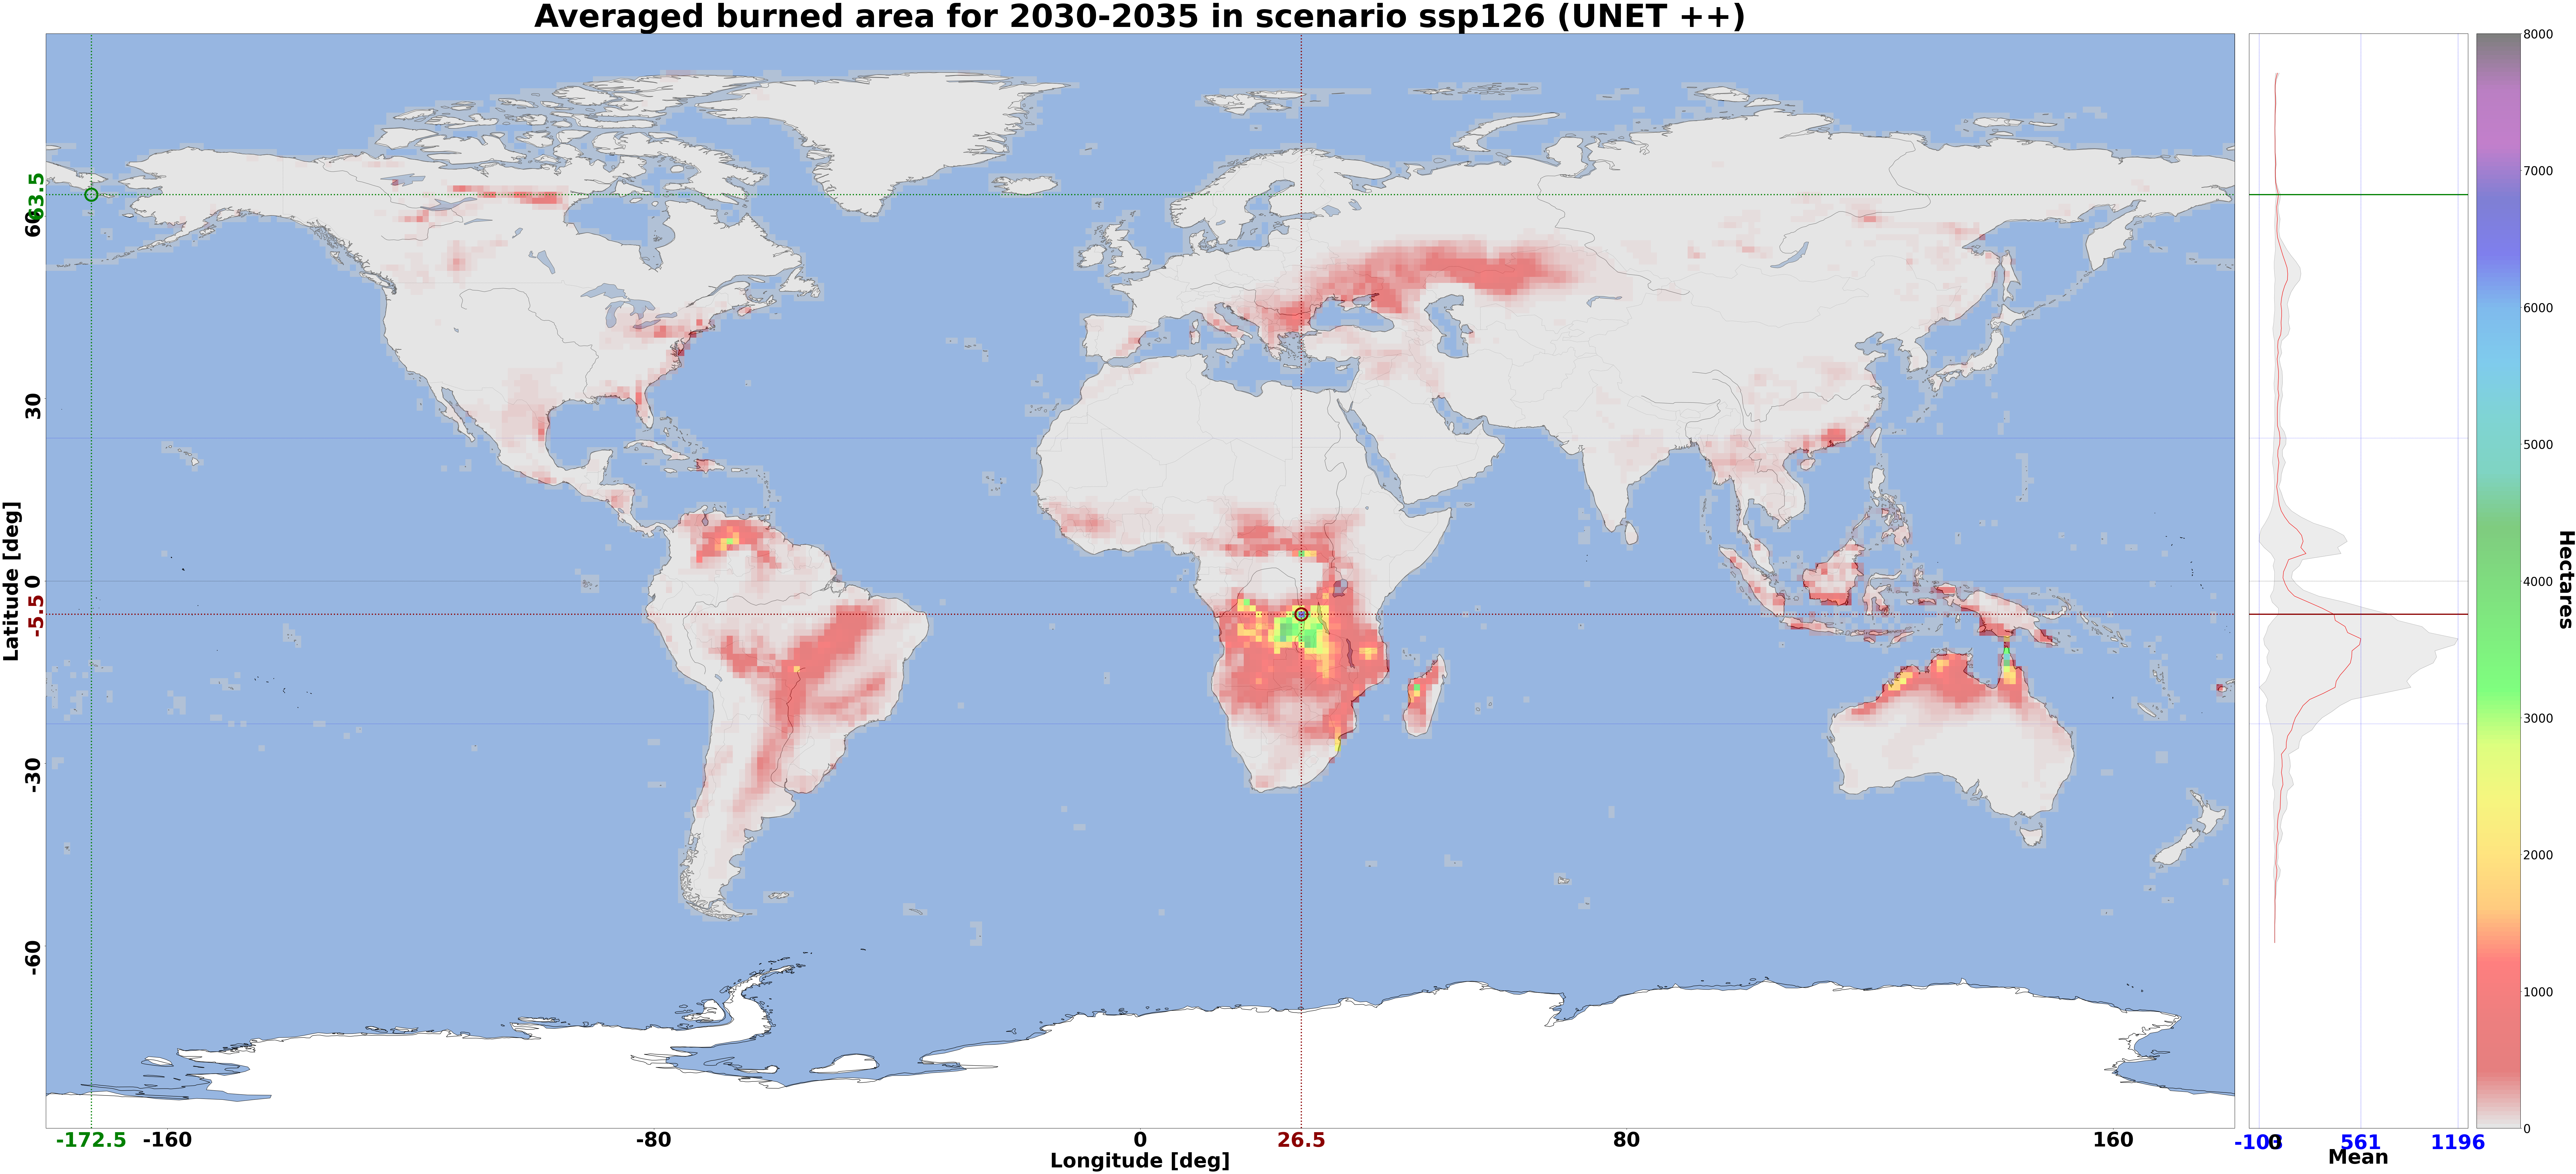

In [8]:
from Fires._utilities.utils_inference import process_and_plot_cmip6infer, process_and_plot_data, load_input_data
input_data = load_input_data(searfire_ds_path, '2019', '2020') # Required by internal setting of variables in Fires._utilities.utils_inference

temporal_aggregate_scheme = {"monthly":[monthly_agg.value,monthly_add_period.value],
                             "yearly":yearly_agg.value,
                            "decadal":decadal_agg.value}

process_and_plot_cmip6infer(
    data=predictions["global_burned_areas"],
    temporal_aggregate_scheme=temporal_aggregate_scheme,
    label=f'Averaged burned area for {year_range.value[0]}-{year_range.value[1]} in scenario {scenario.value}',
    lats=seafire_ds.latitude.values,
    lons=seafire_ds.longitude.values,
    scale_min=0,
    scale_max=8000,
    model_name="Unet ++",
    lat_min=-60  
)

